In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import scipy.sparse as sp
from tqdm import tqdm
from collections import Counter
import time
from scipy.spatial.distance import cdist
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 

import rmm
import cupy
import cudf
import cupy as cp
import cvxpy as cpv
from cuml.metrics import pairwise_distances
from cuml.metrics import nan_euclidean_distances
from rmm.allocators.cupy import rmm_cupy_allocator
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
%%time
fpath = "../../resources/gene_names.tsv.gz"
gdf = pd.read_csv(fpath, sep='\t', low_memory=False)
print(f"{gdf.shape=}")

protein_coding = gdf[gdf['Gene type'] == 'protein_coding']['Gene name'].unique()
print(f"N protein coding: {protein_coding.shape=}")

gdf.shape=(73466, 8)
N protein coding: protein_coding.shape=(18149,)
CPU times: user 138 ms, sys: 18.9 ms, total: 157 ms
Wall time: 169 ms


In [3]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/single_cell_atlas_embedding.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 320 ms, sys: 353 ms, total: 673 ms
Wall time: 4.47 s


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 420366 × 24
    obs: 'annotation', 'cell_type', 'tissue', 'development_stage', 'basename', 'dataset_id', 'data_key', 'data_source', 'celltype', 'source', 'batch_key', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'leiden', 'cluster'
    uns: 'basename_colors', 'cluster_colors', 'data_key_colors', 'leiden', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

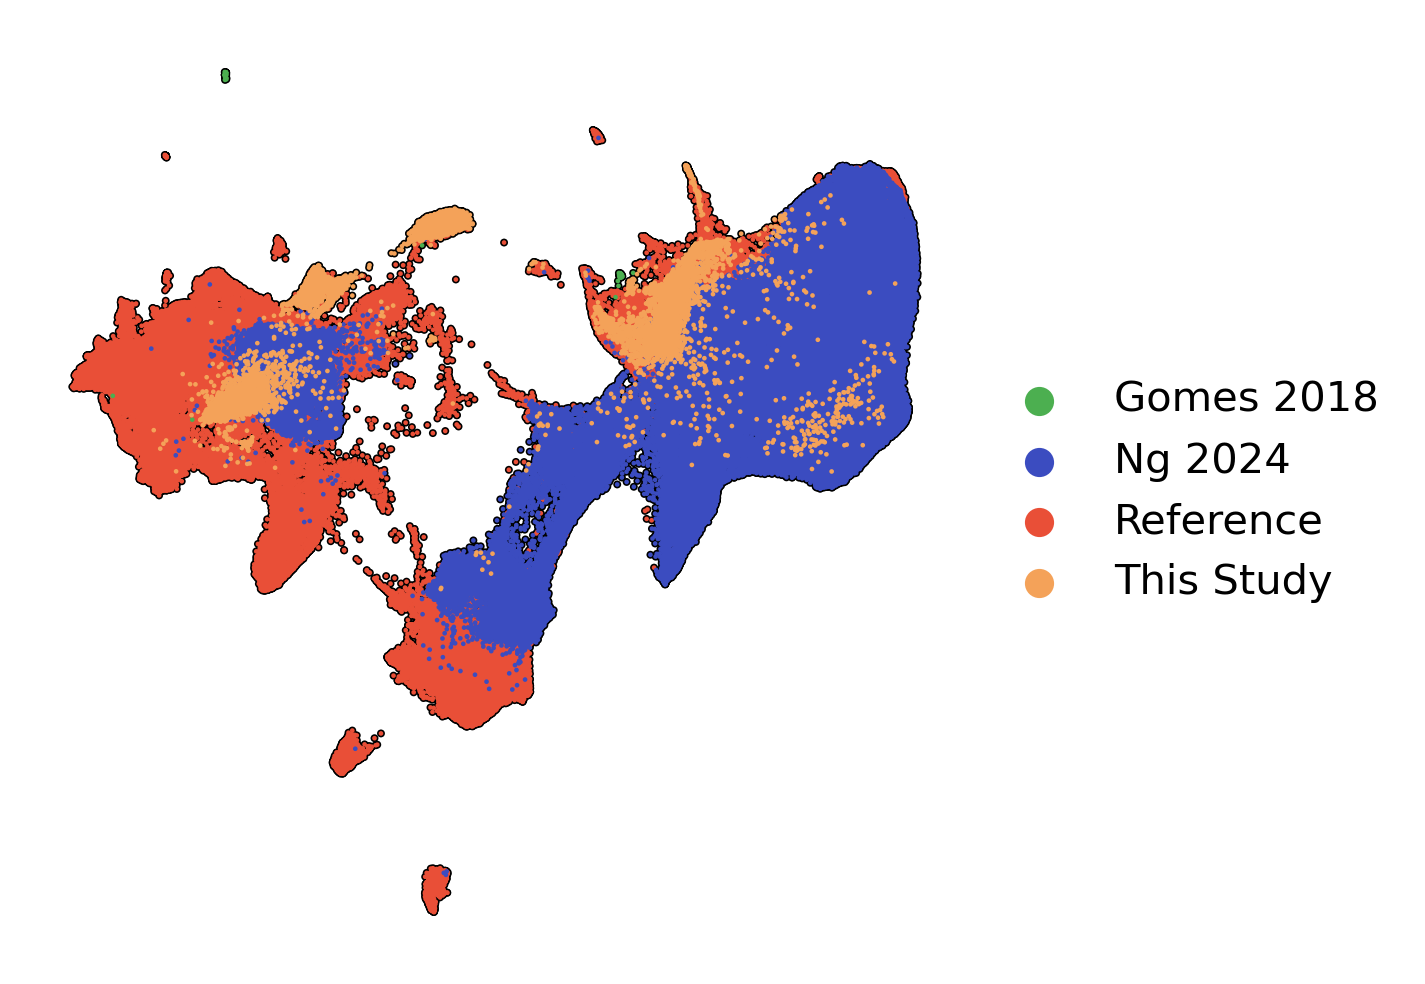

In [4]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

palette = {
    "Ng 2024":     "#3B4CC0",  # strong blue (okabe ito blue)
    "Reference":   "#E94F37",  # vibrant red-orange
    "This Study":  "#F4A259",  # warm, soft orange
    "Gomes 2018":  "#4CAF50",  # natural green (slightly muted)
}

sc.pl.umap(
    adata,
    color='data_key',
    palette=palette,
    # palette='gnuplot2',
    size=5,
    ncols=1,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    title="",
    frameon=False,
    wspace=0.5,
)

# Recluster

cluster2
A5     65399
A7     52413
A10    34767
A16    33956
A15    32723
A21    31379
A1     28625
A12    26277
A4     22747
A6     14871
A14    13324
A2     13170
A3     12904
A11    12106
A8      7495
A9      4904
A13     4076
A17     3519
A19     3172
A18     1279
A20     1032
A22      228


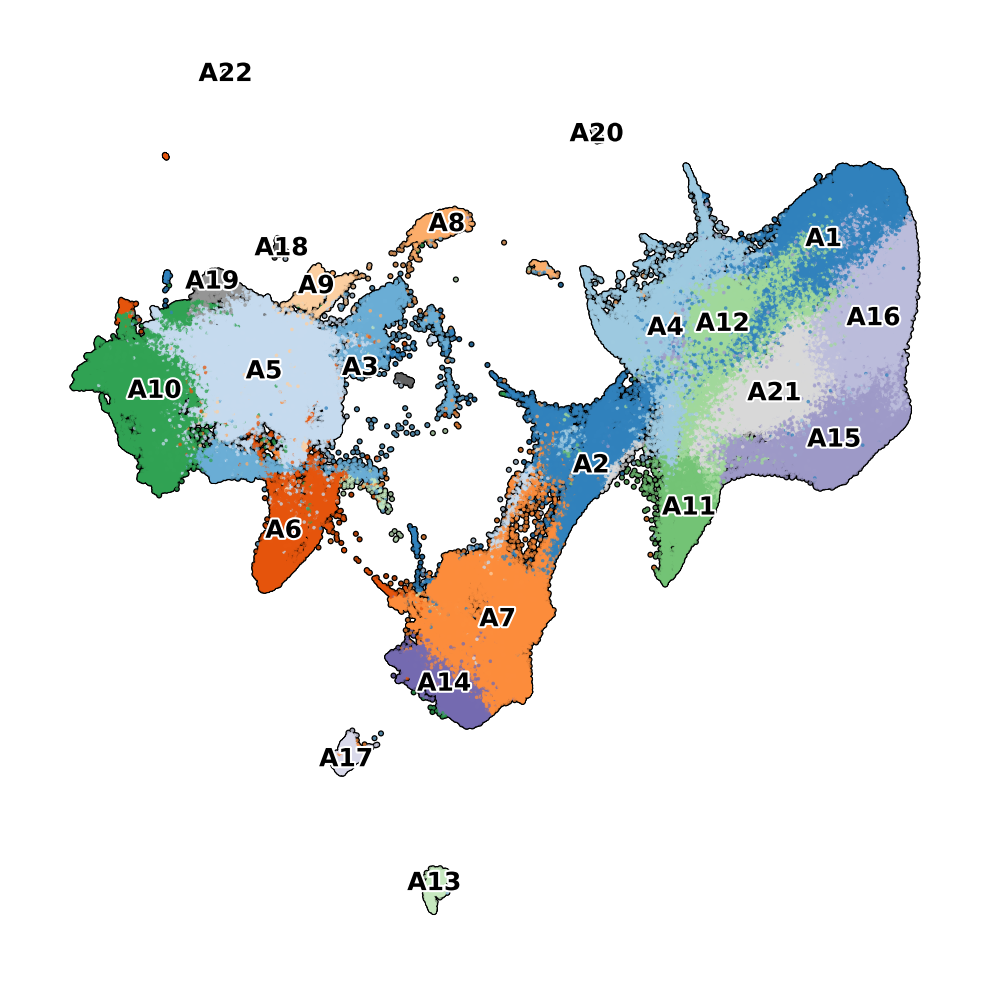

CPU times: user 12.3 s, sys: 1.22 s, total: 13.5 s
Wall time: 13.5 s


In [37]:
%%time 

rsc.tl.leiden(adata, resolution=0.55)

adata.obs['cluster2'] = adata.obs['leiden'].apply(lambda x: f"A{int(x) + 1}")
adata.obs['cluster2'] = adata.obs['cluster2'].astype('str')

print(adata.obs['cluster2'].value_counts().to_string())

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color='cluster2',
    palette='tab20c', 
    size=3,
    ncols=1,
    alpha=0.75,
    legend_loc='on data',
    legend_fontsize=6,
    legend_fontoutline=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    title="",
    frameon=False,
    wspace=0.5,
)

cluster2
A5     65399
A7     52413
A10    34767
A16    33956
A15    32723
A21    31379
A1     28625
A12    26277
A4     22747
A6     14871
A14    13324
A2     13170
A3     12904
A11    12106
A8      7495
A9      4904
A13     4076
A17     3519
A19     3172
A18     1279
A20     1032
A22      228


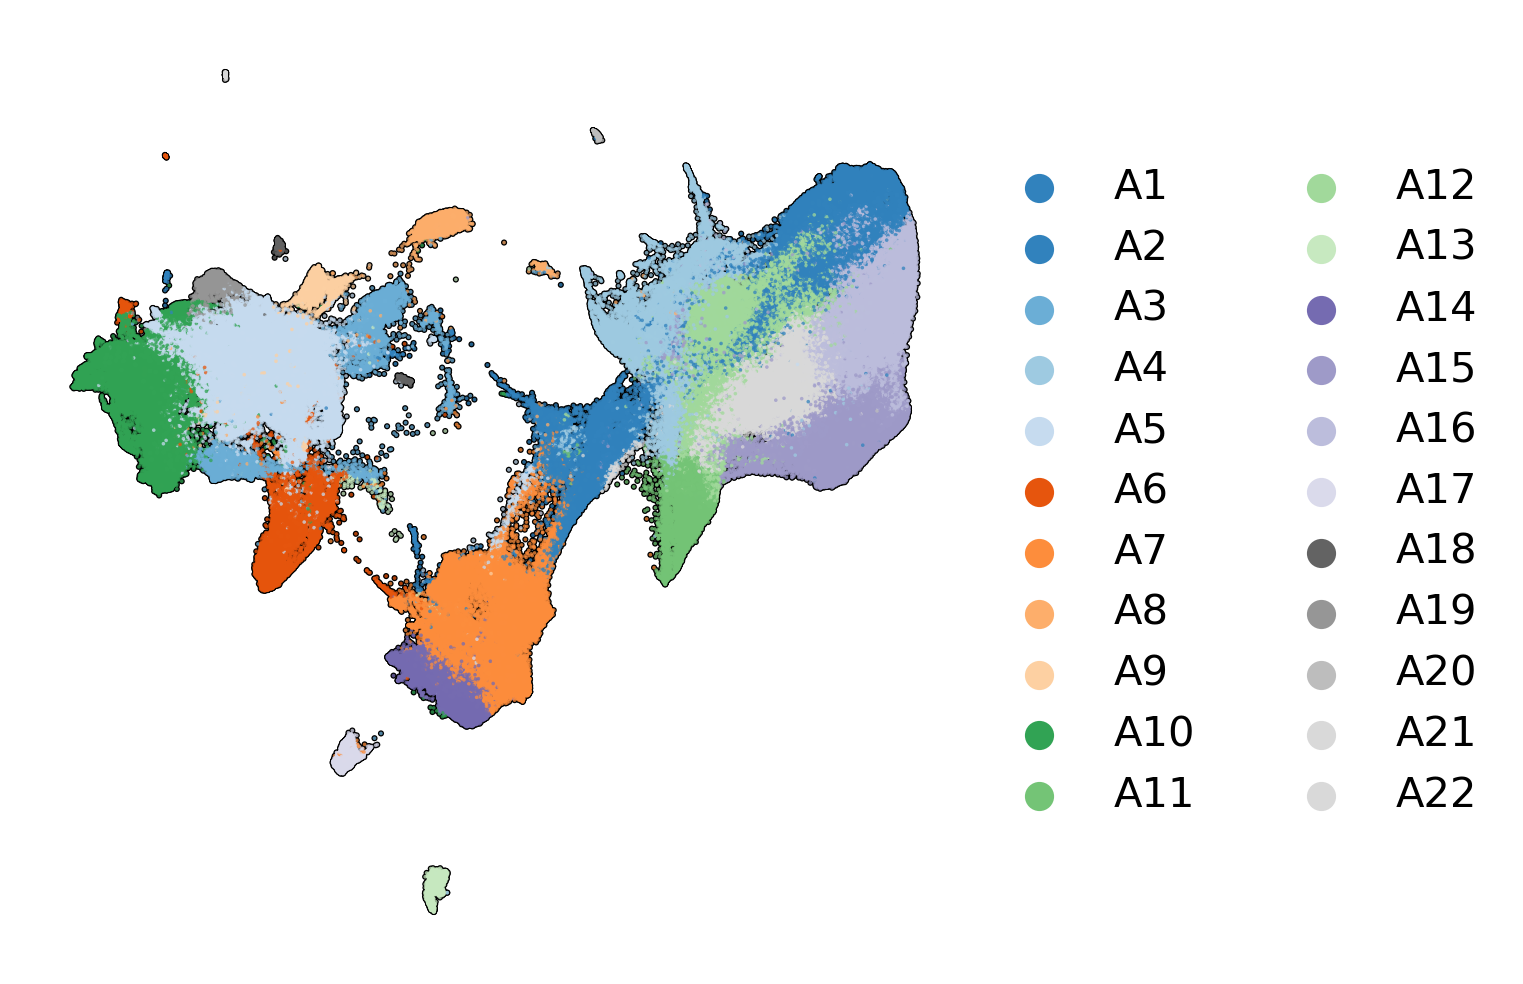

CPU times: user 13 s, sys: 1.57 s, total: 14.5 s
Wall time: 30.8 s


In [5]:
%%time 

rsc.tl.leiden(adata, resolution=0.55)

adata.obs['cluster2'] = adata.obs['leiden'].apply(lambda x: f"A{int(x) + 1}")
adata.obs['cluster2'] = adata.obs['cluster2'].astype('str')

print(adata.obs['cluster2'].value_counts().to_string())

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color='cluster2',
    palette='tab20c', 
    size=3,
    ncols=1,
    alpha=0.75,
    # legend_loc='on data',
    # legend_fontsize=6,
    # legend_fontoutline=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    title="",
    frameon=False,
    wspace=0.5,
)

In [6]:
# Get top 4 most frequent data_keys
data_keys = adata.obs['data_key'].unique()

# Create binary columns directly
for key in data_keys:
    col_name = f"{key}"
    adata.obs[col_name] = (adata.obs['data_key'] == key).astype(int)

adata.obs[data_keys].head()

,Reference,Ng 2024,Gomes 2018,This Study
1257969,1,0,0,0
609700,1,0,0,0
637545,1,0,0,0
543374,1,0,0,0
756827,1,0,0,0


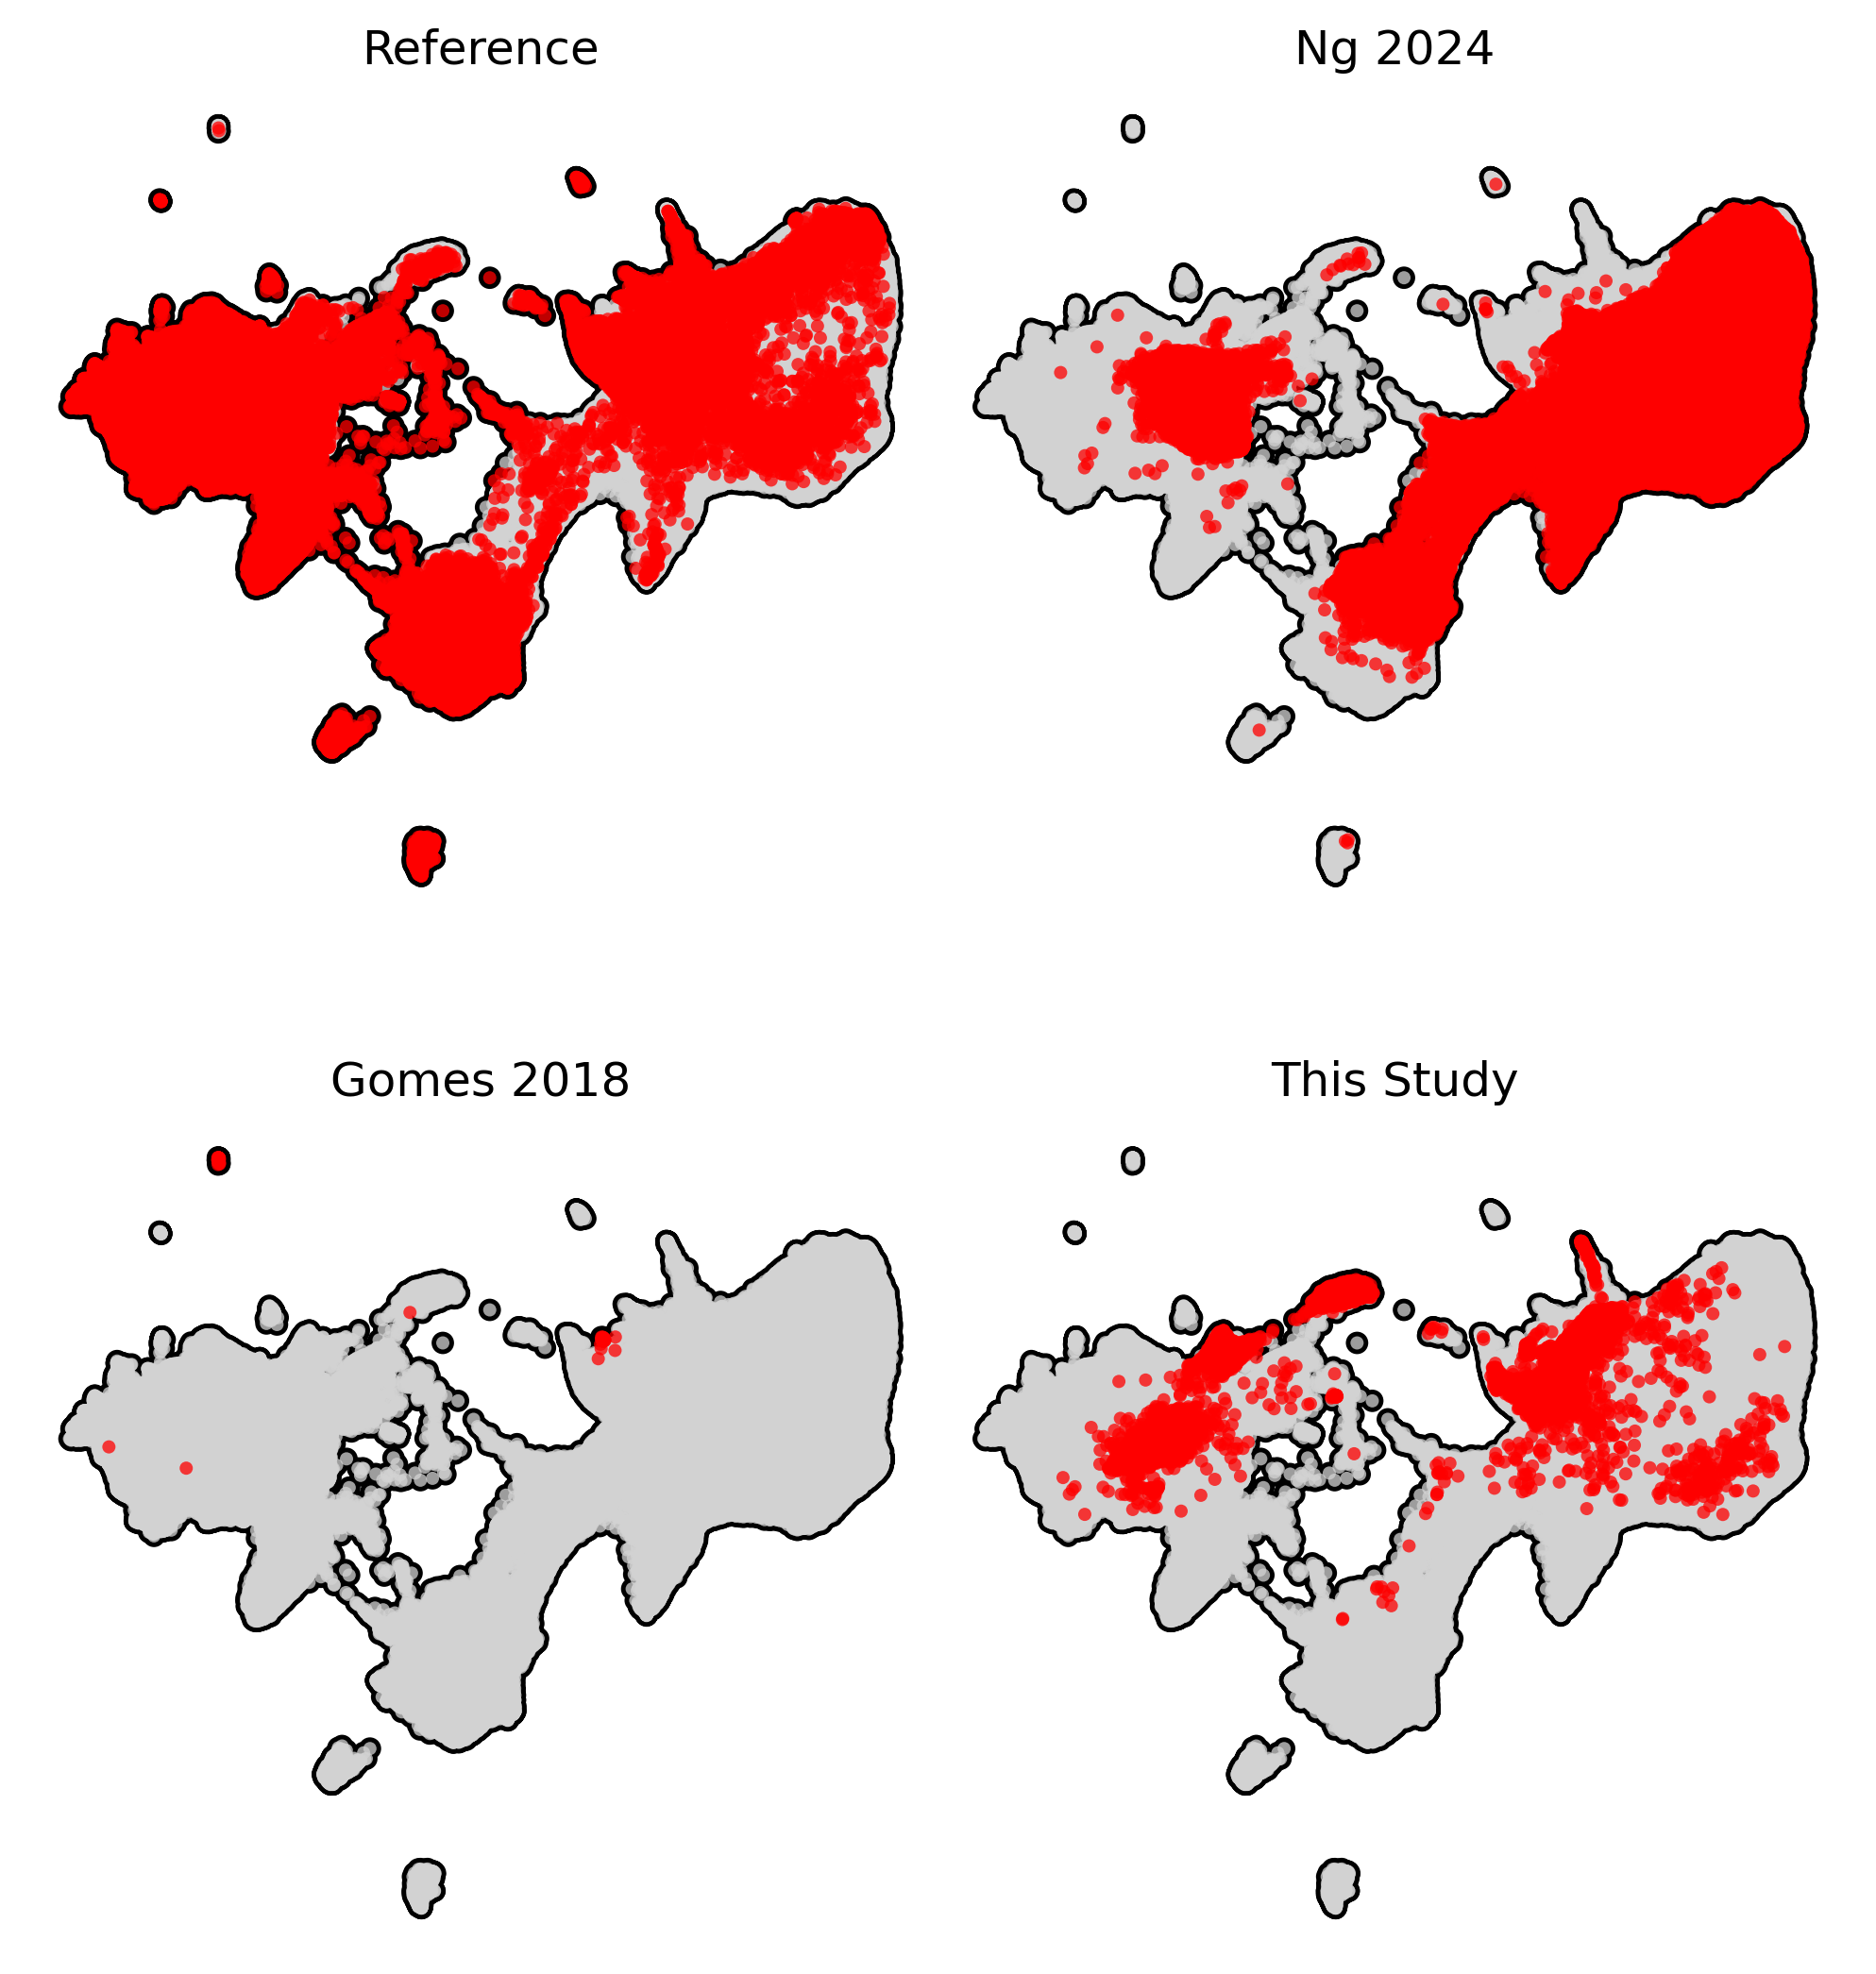

CPU times: user 36.9 s, sys: 121 ms, total: 37 s
Wall time: 37.1 s


In [7]:
%%time 

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

cmap = LinearSegmentedColormap.from_list("grey_red", ["lightgrey", "red"])

sc.pl.umap(
    adata,
    color=data_keys,
    # palette=['lightgrey', 'r'], 
    cmap=cmap, 
    size=45,
    sort_order=True,
    ncols=2,
    alpha=0.75,
    legend_loc=None,
    colorbar_loc=None,
    # legend_loc='on data',
    # legend_fontsize=6,
    # legend_fontoutline=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    # title="",
    frameon=False,
    wspace=0.01,
)

In [8]:
adata.obs.columns

Index(['annotation', 'cell_type', 'tissue', 'development_stage', 'basename',
       'dataset_id', 'data_key', 'data_source', 'celltype', 'source',
       'batch_key', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts',
       'n_genes', 'leiden', 'cluster', 'cluster2', 'Reference', 'Ng 2024',
       'Gomes 2018', 'This Study'],
      dtype='object')

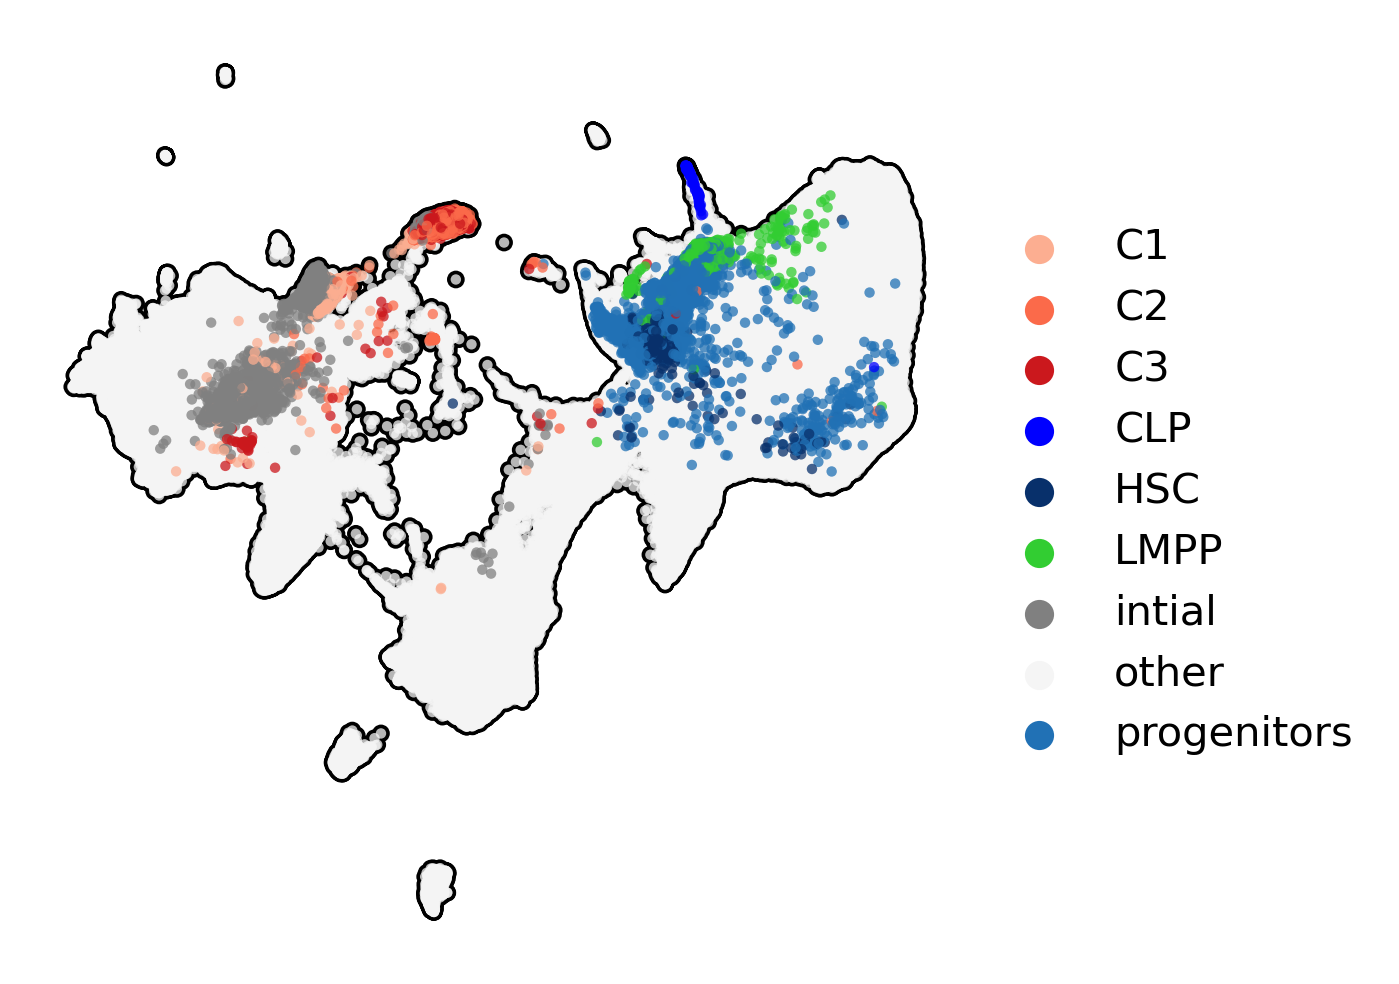

In [9]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

adata.obs['iHSC_annotation'] = np.where(adata.obs['data_key'] == 'This Study', adata.obs['annotation'], 'other')

palette = {
    # HSC group – blues
    'HSC'     : '#08306B',
    # 'MPP'     : '#2171B5',
    # 'CMP'     : '#2171B5',
    'progenitors' : '#2171B5',
    'LMPP'    : 'limegreen',
    'CLP'     : 'blue',

    # reprogram group – reds
    'C1'      : '#FCAE91',
    'C2'      : '#FB6A4A',
    'C3'      : '#CB181D',

    # initial group – neutral grey
    'intial'  : '#808080',
    # 'other' : 'lightgrey',
    'other' : 'whitesmoke',
}

sc.pl.umap(
    adata,
    color='iHSC_annotation',
    palette=palette, 
    size=25,
    ncols=1,
    alpha=0.75,
    # legend_loc='on data',
    # legend_fontsize=9,
    # legend_fontoutline=1.5,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    title="",
    frameon=False,
    wspace=0.5,
)

# Distances

In [20]:
%%time
sdata = sc.get.aggregate(adata, by='cluster2', func='mean')
sdata.X = sdata.layers['mean']

X = sdata.X
print(f"{X.shape=}")

dists = pairwise_distances(X, metric='euclidean')
print(f"{dists.shape=}")

df = pd.DataFrame(
    dists, 
    index=sdata.obs['cluster2'].values,
    columns=sdata.obs['cluster2'].values,
)

df.head()

X.shape=(22, 24)
dists.shape=(22, 22)
CPU times: user 51.7 ms, sys: 5.85 ms, total: 57.5 ms
Wall time: 56.8 ms


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A13,A14,A15,A16,A17,A18,A19,A20,A21,A22
A1,0.000000,3.060437,4.606465,2.393437,5.665557,5.504071,5.403923,3.340626,5.198424,6.171918,...,3.217134,5.701201,2.892373,2.097225,6.296750,7.715248,6.007127,3.059917,3.262797,24.218809
A2,3.060437,0.000000,3.745262,2.542420,4.837953,4.783984,3.496355,3.267683,4.608467,5.764563,...,3.717674,4.206103,2.719358,3.825097,5.137101,6.659205,5.824472,4.446277,3.066291,24.210507
A3,4.606465,3.745262,0.000000,4.594404,2.470849,3.670808,4.652117,2.863928,3.377324,3.546965,...,3.527241,5.707235,4.732391,5.685040,5.516865,4.940633,3.705900,5.420082,5.807771,22.483827
A4,2.393437,2.542420,4.594404,0.000000,6.101253,5.751668,5.542459,3.417701,5.690517,6.595419,...,3.193633,5.817654,2.384471,2.889959,6.537914,8.301899,6.705218,3.291974,2.667811,24.688069
A5,5.665557,4.837953,2.470849,6.101253,0.000000,3.329292,4.590082,4.324419,2.726078,2.209377,...,4.776404,5.675743,6.106951,6.840206,6.190245,3.340672,2.857171,6.658224,7.018540,21.803605


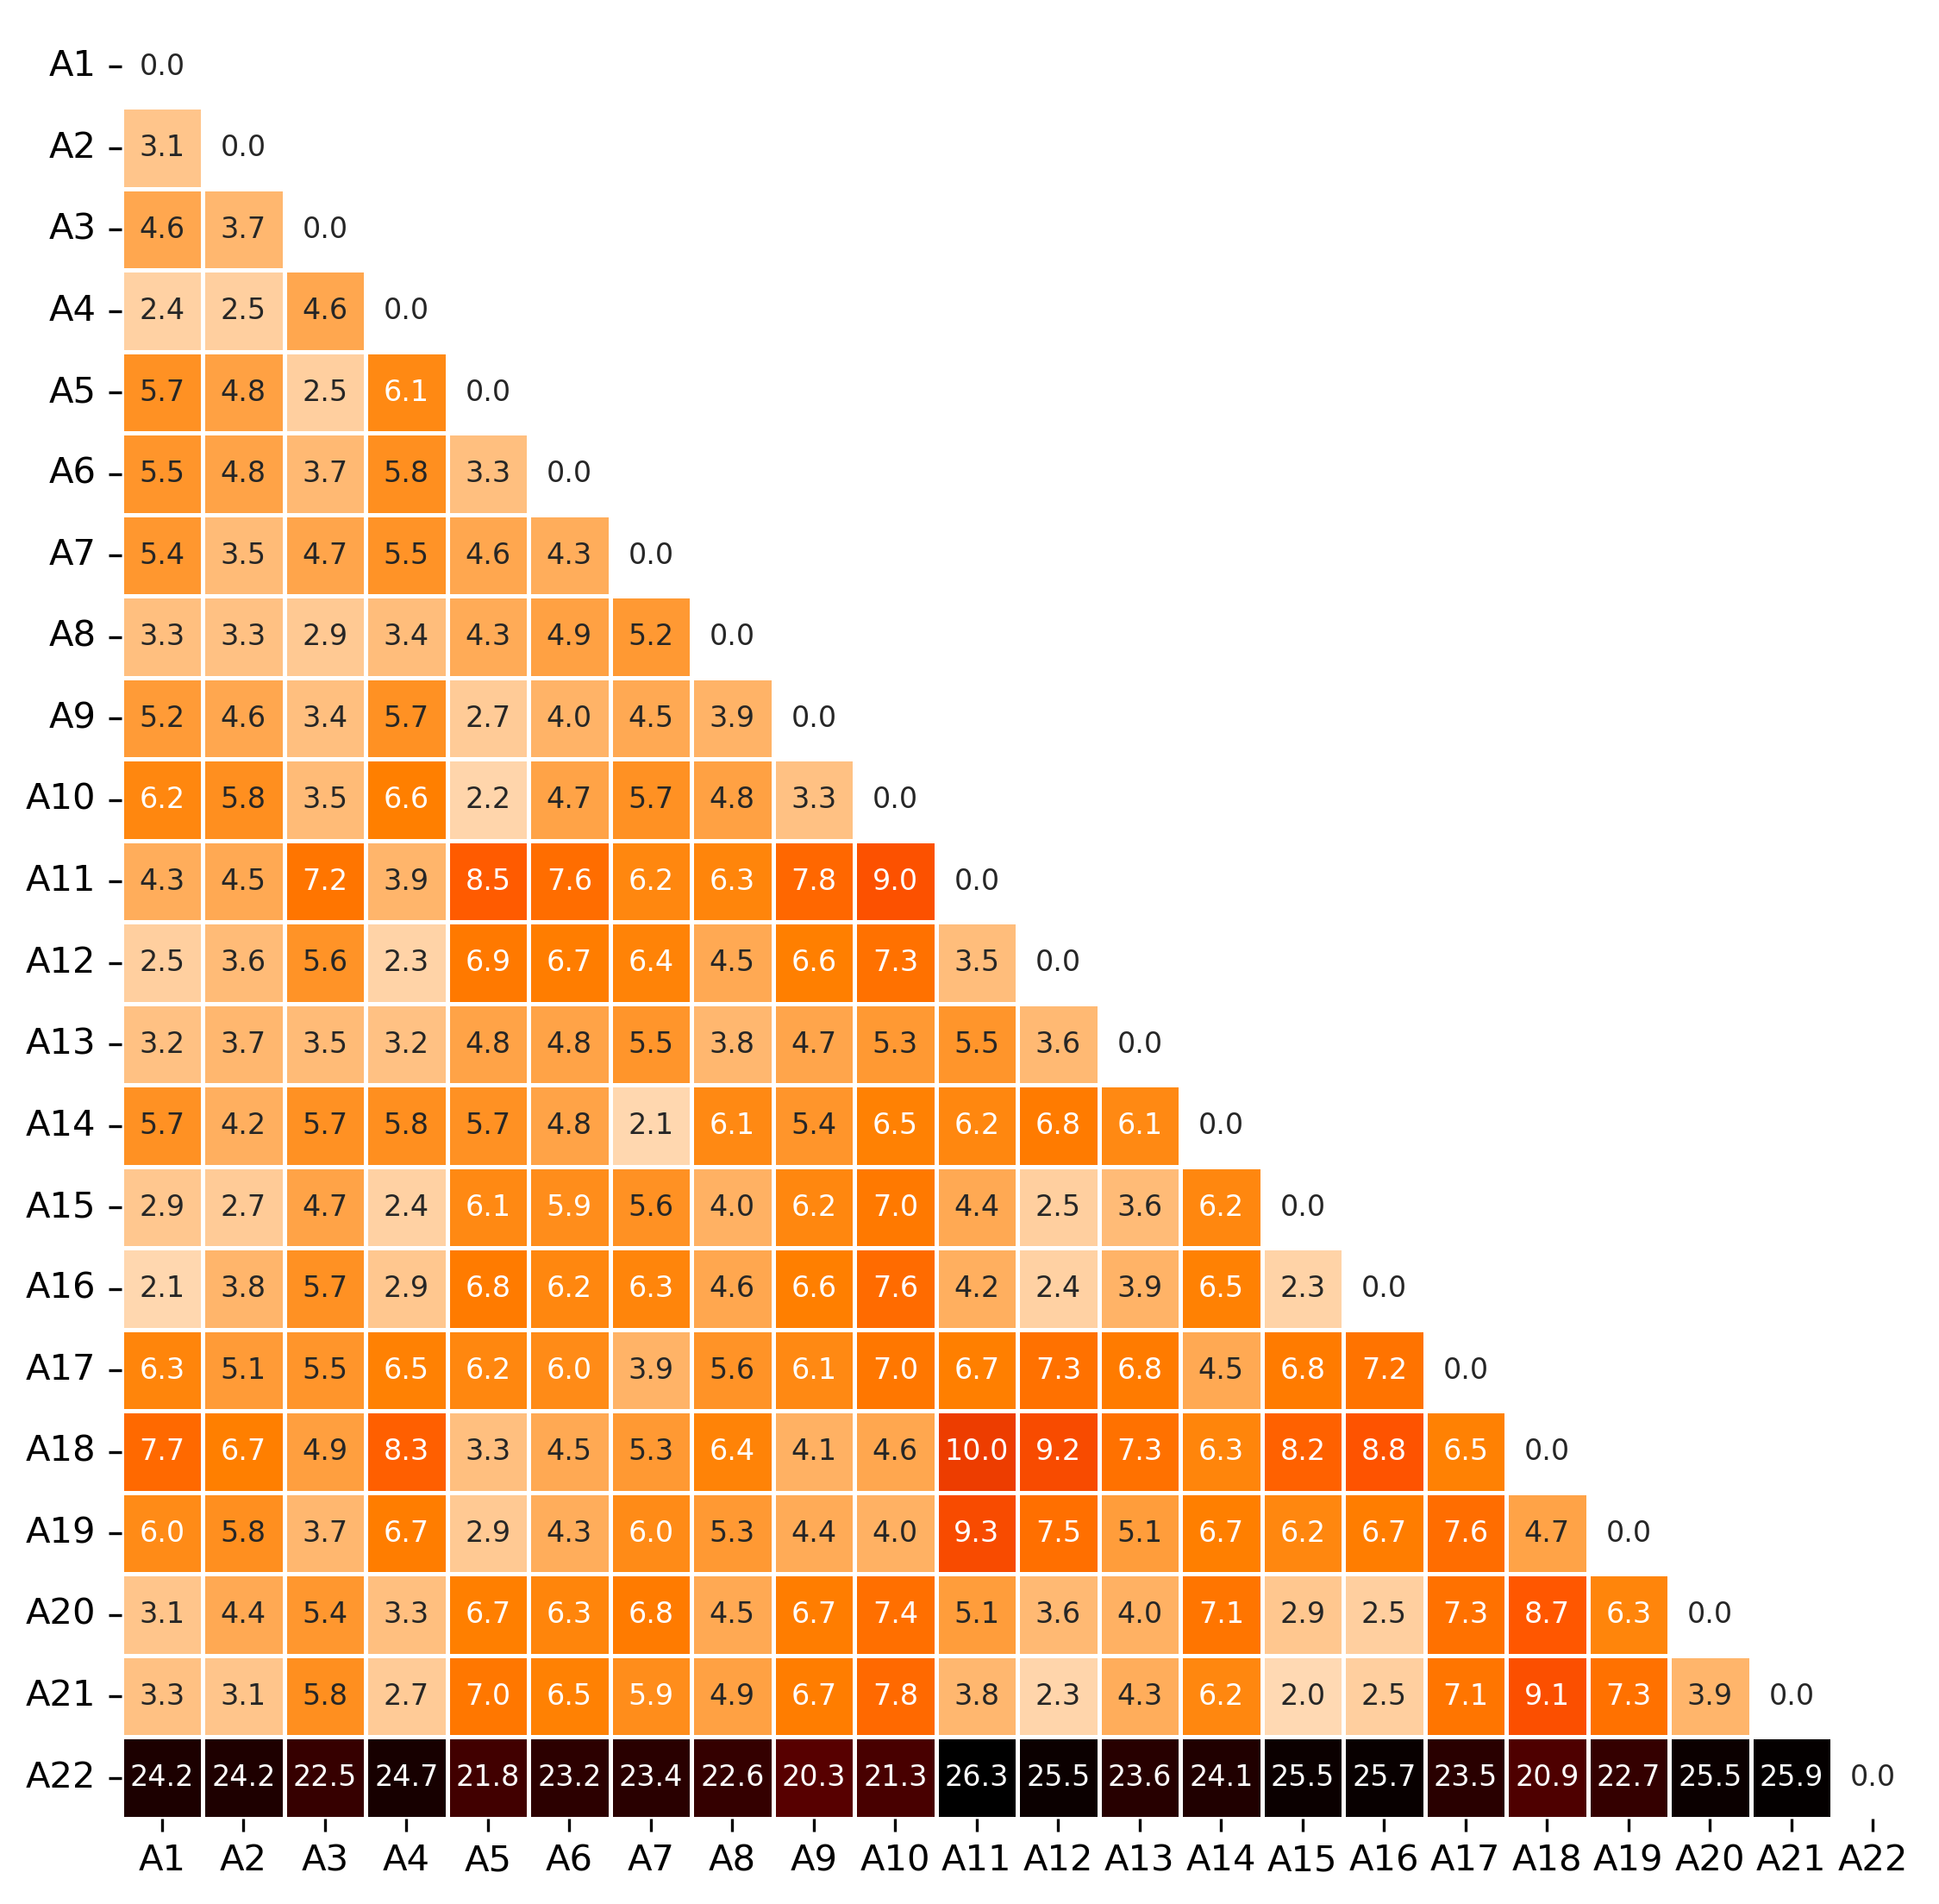

In [31]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 9, 9

pdf = df.copy()
mask = np.triu(np.ones_like(pdf, dtype=bool), k=1)

sns.heatmap(
    pdf, square=True,
    mask=mask,
    cmap='gist_heat_r',
    linewidth=0.75,
    annot=True,
    fmt=".1f",
    annot_kws={'fontsize' : 8},
    cbar=False,
)


plt.xlabel("")
plt.ylabel("")

plt.gca().tick_params(axis='y', rotation=0)

# PAGA

CPU times: user 17.4 s, sys: 994 ms, total: 18.4 s
Wall time: 18.4 s


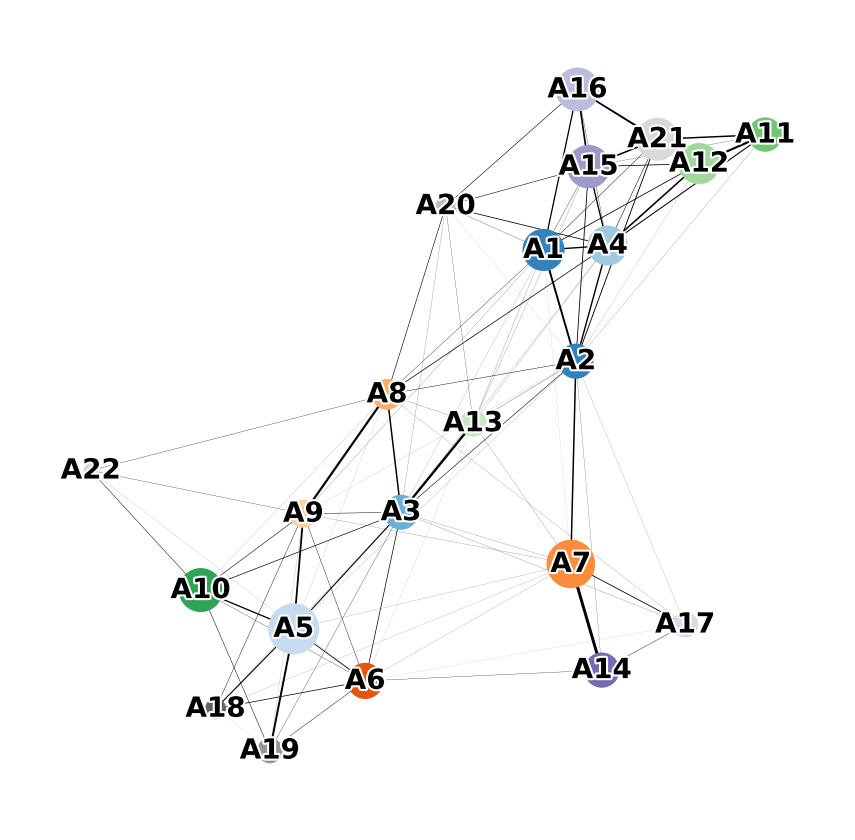

In [35]:
%%time
# plot the embedding
sc.tl.paga(adata, groups='cluster2')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5
ax = sc.pl.paga(
    adata, 
    fontoutline=1.5, 
    edge_width_scale=0.25,  
    frameon=False,  
    show=False,
)

ax.set_facecolor('none')    # axes background
plt.gcf().set_facecolor('none')    # figure background

# Store Metadata

In [ ]:
df = adata.obs.copy()
cluster_column = 'cluster2'

rows = []

for cluster, group in df.groupby(cluster_column):
    total = len(group)

    # Get top 10 (annotation, data_key) pairs
    pairs = list(zip(group['annotation'], group['data_key']))
    top10 = Counter(pairs).most_common(5)

    for (ann, dk), count in top10:
        rows.append({
            'cluster': cluster,
            'annotation': ann,
            'data_key': dk,
            'count': count,
            'proportion': round(count / total, 3)
        })

# Create DataFrame
summary_df = pd.DataFrame(rows)

# Optional: sort by cluster and count
summary_df = summary_df.sort_values(['cluster', 'count'], ascending=[True, False])

# Display
print(f"{summary_df.shape=}")

outpath = "../../results/reference_clusters.tex"

summary_df.to_latex(
    outpath,
    index=False,
    longtable=True,
    escape=True,  # set to True if your data has LaTeX-sensitive characters
    caption="Top 10 annotation-data_key pairs by cluster.",
    label="tab:cluster_summary"
)

summary_df.head()


In [36]:
df = adata.obs.copy()

cluster_column = 'cluster2'

for cluster, group in df.groupby(cluster_column):
    print(f"\n ===== Cluster: {cluster} ===== ")

    # Get (annotation, data_key) pairs
    pairs = list(zip(group['annotation'], group['data_key']))
    top10 = Counter(pairs).most_common(10)
    total = len(group)

    # Format: "annotation (data_key, proportion)"
    print("\nTop 10 cell types:")
    for (ann, dk), count in top10:
        prop = count / total
        print(f"\t{ann} ({dk}, {prop:.3f})")
    
    counts = group['data_key'].value_counts()
    norm = group['data_key'].value_counts(normalize=True).round(3)
    
    # Combine into one DataFrame
    summary = pd.DataFrame({
        'count': counts,
        'proportion': norm
    })
    print()
    print(summary.to_string())


 ===== Cluster: A1 ===== 

Top 10 cell types:
	Mye Pro1 (Ng 2024, 0.197)
	Gran (Ng 2024, 0.186)
	Mono (Ng 2024, 0.170)
	Mye Pro2 (Ng 2024, 0.126)
	HSPC1 (Ng 2024, 0.120)
	hematopoietic cell (Reference, 0.054)
	HSPC2 (Ng 2024, 0.028)
	EMK Pro1 (Ng 2024, 0.021)
	granulocyte monocyte progenitor cell (Reference, 0.016)
	HSPC3 (Ng 2024, 0.015)

            count  proportion
data_key                     
Ng 2024     25181       0.880
Reference    3308       0.116
This Study    136       0.005
Gomes 2018      0       0.000

 ===== Cluster: A2 ===== 

Top 10 cell types:
	HSPC1 (Ng 2024, 0.329)
	Hemogenic (Ng 2024, 0.238)
	HSPC2 (Ng 2024, 0.110)
	EMK Pro1 (Ng 2024, 0.080)
	EMK Pro2 (Ng 2024, 0.045)
	Gran (Ng 2024, 0.029)
	Mye Pro1 (Ng 2024, 0.027)
	Mye Pro2 (Ng 2024, 0.026)
	Mono (Ng 2024, 0.025)
	HSPC3 (Ng 2024, 0.013)

            count  proportion
data_key                     
Ng 2024     12416       0.943
Reference     640       0.049
This Study    114       0.009
Gomes 2018      0       0

/tmp/ipykernel_330483/380739730.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cluster, group in df.groupby(cluster_column):


In [ ]:
break